# 📊 Sales Analytics Dashboard

**A comprehensive end-to-end Sales Analytics project**

This notebook covers:
1. **Synthetic Data Generation** — 50,000+ realistic sales records
2. **Data Cleaning** — Missing values, duplicates, type corrections
3. **Outlier Detection** — IQR-based detection and capping
4. **Feature Engineering** — Temporal features, profit margins, order sizing
5. **KPI Dashboard** — Total Sales, Profit, AOV, Customer Count
6. **15+ Professional Visualizations** — Answering key business questions
7. **Summary & Recommendations**

---
**Author:** Sujal Giri | **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## 1. Setup & Library Imports

Importing all required libraries for data manipulation, visualization, and analysis.

In [1]:
# ============================================================
# 1. SETUP & LIBRARY IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import random
from datetime import datetime, timedelta

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Set global plot style for professional aesthetics
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'font.family': 'sans-serif',
})

# Seed for reproducibility
np.random.seed(42)
random.seed(42)

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATASET_DIR = os.path.join(BASE_DIR, 'Dataset')
IMAGES_DIR = os.path.join(BASE_DIR, 'Images')

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)

print('✅ Libraries imported successfully!')
print(f'✅ Dataset directory: {DATASET_DIR}')
print(f'✅ Images directory : {IMAGES_DIR}')

✅ Libraries imported successfully!
✅ Dataset directory: /Users/sujalgiri/Sales Analytics/Sales_Analytics_Project/Dataset
✅ Images directory : /Users/sujalgiri/Sales Analytics/Sales_Analytics_Project/Images


## 2. Synthetic Dataset Generation

Generating a realistic sales dataset with **50,000+ records** across 16 columns.

The dataset simulates 4 years of Indian e-commerce sales data (2021–2024) with:
- **~2,000 unique customers** across 29 Indian states
- **3 product categories** with 17 sub-categories and ~200 products
- **Realistic distributions** for sales, profit, quantity, and discounts
- **Intentional imperfections** (missing values, duplicates) for cleaning practice

In [2]:
# ============================================================
# 2. SYNTHETIC DATASET GENERATION
# ============================================================

# --- 2a. Define reference data ---

# Indian states mapped to regions and cities
STATE_CITY_MAP = {
    # North
    'Delhi': ['New Delhi', 'Dwarka', 'Rohini'],
    'Uttar Pradesh': ['Lucknow', 'Noida', 'Agra', 'Varanasi', 'Kanpur'],
    'Haryana': ['Gurugram', 'Faridabad', 'Karnal'],
    'Punjab': ['Chandigarh', 'Ludhiana', 'Amritsar'],
    'Rajasthan': ['Jaipur', 'Udaipur', 'Jodhpur', 'Kota'],
    'Uttarakhand': ['Dehradun', 'Haridwar', 'Rishikesh'],
    'Himachal Pradesh': ['Shimla', 'Manali', 'Dharamshala'],
    'Jammu & Kashmir': ['Srinagar', 'Jammu'],
    # South
    'Tamil Nadu': ['Chennai', 'Coimbatore', 'Madurai', 'Salem'],
    'Karnataka': ['Bengaluru', 'Mysuru', 'Hubli', 'Mangaluru'],
    'Kerala': ['Kochi', 'Thiruvananthapuram', 'Kozhikode'],
    'Telangana': ['Hyderabad', 'Warangal', 'Nizamabad'],
    'Andhra Pradesh': ['Visakhapatnam', 'Vijayawada', 'Tirupati'],
    # East
    'West Bengal': ['Kolkata', 'Howrah', 'Durgapur', 'Siliguri'],
    'Bihar': ['Patna', 'Gaya', 'Muzaffarpur'],
    'Odisha': ['Bhubaneswar', 'Cuttack', 'Rourkela'],
    'Jharkhand': ['Ranchi', 'Jamshedpur', 'Dhanbad'],
    'Assam': ['Guwahati', 'Dibrugarh', 'Silchar'],
    # West
    'Maharashtra': ['Mumbai', 'Pune', 'Nagpur', 'Nashik', 'Thane'],
    'Gujarat': ['Ahmedabad', 'Surat', 'Vadodara', 'Rajkot'],
    'Madhya Pradesh': ['Bhopal', 'Indore', 'Jabalpur', 'Gwalior'],
    'Goa': ['Panaji', 'Margao'],
    'Chhattisgarh': ['Raipur', 'Bilaspur', 'Durg'],
    # Additional
    'Chandigarh': ['Chandigarh'],
    'Tripura': ['Agartala'],
    'Meghalaya': ['Shillong'],
    'Manipur': ['Imphal'],
    'Nagaland': ['Dimapur', 'Kohima'],
    'Sikkim': ['Gangtok'],
}

STATE_REGION_MAP = {
    'Delhi': 'North', 'Uttar Pradesh': 'North', 'Haryana': 'North',
    'Punjab': 'North', 'Rajasthan': 'North', 'Uttarakhand': 'North',
    'Himachal Pradesh': 'North', 'Jammu & Kashmir': 'North', 'Chandigarh': 'North',
    'Tamil Nadu': 'South', 'Karnataka': 'South', 'Kerala': 'South',
    'Telangana': 'South', 'Andhra Pradesh': 'South',
    'West Bengal': 'East', 'Bihar': 'East', 'Odisha': 'East',
    'Jharkhand': 'East', 'Assam': 'East', 'Tripura': 'East',
    'Meghalaya': 'East', 'Manipur': 'East', 'Nagaland': 'East', 'Sikkim': 'East',
    'Maharashtra': 'West', 'Gujarat': 'West', 'Madhya Pradesh': 'West',
    'Goa': 'West', 'Chhattisgarh': 'West',
}

# State population weights (approximate, for realistic distribution)
STATE_WEIGHTS = {
    'Maharashtra': 12, 'Uttar Pradesh': 14, 'Tamil Nadu': 8, 'Karnataka': 8,
    'Gujarat': 7, 'Delhi': 9, 'Telangana': 6, 'West Bengal': 7,
    'Rajasthan': 5, 'Kerala': 5, 'Madhya Pradesh': 4, 'Haryana': 4,
    'Bihar': 4, 'Punjab': 3, 'Andhra Pradesh': 4, 'Odisha': 3,
    'Jharkhand': 2, 'Assam': 2, 'Uttarakhand': 2, 'Chhattisgarh': 2,
    'Goa': 1, 'Himachal Pradesh': 1, 'Jammu & Kashmir': 1, 'Chandigarh': 1,
    'Tripura': 0.5, 'Meghalaya': 0.5, 'Manipur': 0.3, 'Nagaland': 0.3, 'Sikkim': 0.2,
}

states_list = list(STATE_WEIGHTS.keys())
state_probs = np.array(list(STATE_WEIGHTS.values()), dtype=float)
state_probs /= state_probs.sum()

print(f'✅ Reference data defined: {len(states_list)} states, {len(STATE_CITY_MAP)} city mappings')

✅ Reference data defined: 29 states, 29 city mappings


In [3]:
# --- 2b. Define product catalog ---

# Category -> Sub-Category -> Product Names mapping
PRODUCT_CATALOG = {
    'Technology': {
        'Phones': ['Samsung Galaxy S23', 'iPhone 15 Pro', 'OnePlus 12', 'Google Pixel 8',
                   'Xiaomi 14', 'Vivo V30', 'Realme GT 5', 'Motorola Edge 40',
                   'Oppo Reno 11', 'Nothing Phone 2'],
        'Laptops': ['Dell Inspiron 15', 'HP Pavilion 14', 'Lenovo IdeaPad Slim 5',
                    'MacBook Air M2', 'ASUS VivoBook 15', 'Acer Aspire 7',
                    'MSI Modern 14', 'HP Spectre x360', 'Dell XPS 13', 'Lenovo ThinkPad E14'],
        'Tablets': ['iPad Air 5th Gen', 'Samsung Galaxy Tab S9', 'Lenovo Tab P12',
                    'OnePlus Pad', 'Xiaomi Pad 6', 'Realme Pad X'],
        'Accessories': ['Boat Airdopes 441', 'JBL Tune 760NC', 'Sony WH-1000XM5',
                        'Apple AirPods Pro 2', 'Samsung Galaxy Buds 2 Pro',
                        'Logitech MX Master 3S', 'Anker PowerCore 20000',
                        'SanDisk Ultra 128GB', 'Zebronics Zeb-Transformer'],
        'Printers': ['HP LaserJet Pro M404', 'Canon PIXMA G3060', 'Epson L3250',
                     'Brother DCP-T426W', 'HP DeskJet 2723'],
    },
    'Furniture': {
        'Chairs': ['ErgoFlex Office Chair', 'GreenSoul Monster Ultimate',
                   'IKEA Markus Chair', 'Featherlite Optima', 'Wakefit Albus High Back',
                   'Cellbell C104 Mesh', 'Savya Home Apex'],
        'Tables': ['IKEA MALM Desk', 'Wakefit Taurus Study Table', 'Nilkamal Dura Desk',
                   'Solimo Engineered Wood Table', 'HomeTown Zeti Desk',
                   'Urban Ladder Graham Desk'],
        'Bookcases': ['Urban Ladder Alberto Bookshelf', 'IKEA KALLAX Shelf Unit',
                      'Nilkamal Freedom Cabinet', 'Solimo 3-Shelf Bookcase',
                      'Amazon Basics 5-Shelf'],
        'Furnishings': ['Solimo Curtain Set', 'Story@Home Cushion Covers',
                        'SPACES Allegro Bath Towel', 'Kuber Industries Storage Box',
                        'Amazon Basics Bed Sheet Set', 'Cortina Blackout Curtains'],
    },
    'Office Supplies': {
        'Paper': ['JK Copier A4 Paper', 'Classmate A4 Ruled Register',
                  'HP Everyday Copy Paper', 'Oddy A4 Copier Paper',
                  'Navneet Notebook Pack of 6', 'Post-it Super Sticky Notes'],
        'Binders': ['Solo Clip File A4', 'Cello Academy Ring Binder',
                    'Saya Ring Binder', 'Classmate 3-Ring Binder',
                    'Avery Economy Binder'],
        'Art Supplies': ['Camlin Kokuyo Color Pens', 'Faber-Castell Connector Pen Set',
                         'Doms Painting Kit', 'Staedtler Triplus Color',
                         'Camel Drawing Pencils', 'Sakura Pigma Micron'],
        'Storage': ['Cello Stationery Organizer', 'Nilkamal Storage Drawer',
                    'Amazon Basics Desk Organizer', 'Solo A4 Document Case',
                    'Kuber Industries File Rack'],
        'Labels': ['Avery Easy Peel Labels', 'Brother P-touch Label Tape',
                   'Dymo LabelWriter Labels', 'Oddy Label Stickers'],
        'Envelopes': ['Premium White Envelopes Pack', 'Superb Brown Envelopes',
                      'Classmate Craft Envelope Set', 'JK Bubble Mailer Pack'],
        'Fasteners': ['Kangaro Stapler HD-10D', 'Kangaro Staples No.10',
                      'Cello Paper Clips Box', 'Solo Binder Clips Set',
                      'Camlin Adhesive Tape Roll'],
        'Pens': ['Cello Finegrip Ball Pen Pack', 'Reynolds Trimax Gel Pen',
                 'Parker Vector Standard', 'Pilot V5 Liquid Ink',
                 'Uniball Signo 207', 'Classmate Octane Gel Pen'],
    }
}

# Flatten catalog for quick lookup
category_subcategory_products = []
for cat, subcats in PRODUCT_CATALOG.items():
    for subcat, products in subcats.items():
        for product in products:
            category_subcategory_products.append((cat, subcat, product))

print(f'✅ Product catalog: {len(PRODUCT_CATALOG)} categories, '
      f'{sum(len(v) for v in PRODUCT_CATALOG.values())} sub-categories, '
      f'{len(category_subcategory_products)} products')

✅ Product catalog: 3 categories, 17 sub-categories, 105 products


In [4]:
# --- 2c. Generate customer pool ---

FIRST_NAMES = [
    'Aarav', 'Vivaan', 'Aditya', 'Vihaan', 'Arjun', 'Sai', 'Reyansh', 'Ayaan',
    'Krishna', 'Ishaan', 'Shaurya', 'Atharva', 'Advik', 'Pranav', 'Advaith',
    'Dhruv', 'Kabir', 'Ritvik', 'Aarush', 'Kayaan', 'Darsh', 'Veer', 'Yash',
    'Rohan', 'Arnav', 'Dev', 'Ananya', 'Diya', 'Saanvi', 'Aadhya', 'Isha',
    'Priya', 'Riya', 'Aanya', 'Kiara', 'Navya', 'Pari', 'Anika', 'Meera',
    'Nisha', 'Kavya', 'Tanvi', 'Shreya', 'Pooja', 'Neha', 'Sanya', 'Trisha',
    'Mahira', 'Zara', 'Myra', 'Tara', 'Anvi', 'Ahana', 'Divya', 'Sneha',
    'Rakesh', 'Suresh', 'Mahesh', 'Rajesh', 'Amit', 'Sumit', 'Nikhil', 'Sahil',
    'Rahul', 'Vikram', 'Karan', 'Ravi', 'Deepak', 'Manish', 'Sanjay', 'Ajay',
    'Vijay', 'Gaurav', 'Harish', 'Neeraj', 'Prateek', 'Ankur', 'Varun', 'Kunal',
]

LAST_NAMES = [
    'Sharma', 'Verma', 'Gupta', 'Singh', 'Kumar', 'Patel', 'Reddy', 'Nair',
    'Iyer', 'Menon', 'Das', 'Chatterjee', 'Banerjee', 'Mukherjee', 'Roy',
    'Bose', 'Sen', 'Ghosh', 'Dutta', 'Pillai', 'Rao', 'Naidu', 'Choudhury',
    'Joshi', 'Thakur', 'Malhotra', 'Kapoor', 'Khanna', 'Mehta', 'Shah',
    'Desai', 'Jain', 'Agarwal', 'Pandey', 'Mishra', 'Tiwari', 'Dubey',
    'Saxena', 'Bhatia', 'Chauhan', 'Rathore', 'Yadav', 'Rawat', 'Bhatt',
    'Kulkarni', 'Patil', 'Deshpande', 'Kamath', 'Hegde', 'Shetty',
]

# Generate ~2000 unique customer names
NUM_CUSTOMERS = 2000
customer_names = list(set(
    f'{random.choice(FIRST_NAMES)} {random.choice(LAST_NAMES)}'
    for _ in range(NUM_CUSTOMERS * 2)
))[:NUM_CUSTOMERS]

# Assign Customer IDs
customer_id_map = {name: f'CUST-{i+1:04d}' for i, name in enumerate(customer_names)}

print(f'✅ Generated {len(customer_names)} unique customers')

✅ Generated 2000 unique customers


In [5]:
# --- 2d. Generate 50,000+ records ---

NUM_RECORDS = 50500  # Slightly over 50k to account for any filtering

# Date range: 2021-01-01 to 2024-12-31
start_date = datetime(2021, 1, 1)
end_date = datetime(2024, 12, 31)
date_range_days = (end_date - start_date).days

# Payment modes and ship modes with weights
PAYMENT_MODES = ['COD', 'Online', 'Cards']
PAYMENT_WEIGHTS = [0.30, 0.45, 0.25]

SHIP_MODES = ['Standard Class', 'Second Class', 'First Class', 'Same Day']
SHIP_WEIGHTS = [0.55, 0.25, 0.12, 0.08]

DISCOUNT_VALUES = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
DISCOUNT_WEIGHTS = [0.25, 0.20, 0.20, 0.15, 0.10, 0.06, 0.04]

# Category-wise sales and profit parameters
SALES_PARAMS = {
    'Technology':       {'mean': 8.0, 'std': 1.2, 'min': 500,  'max': 50000},
    'Furniture':        {'mean': 7.5, 'std': 1.0, 'min': 200,  'max': 30000},
    'Office Supplies':  {'mean': 5.5, 'std': 1.5, 'min': 50,   'max': 5000},
}

PROFIT_MARGIN = {
    'Technology':      {'mean': 0.15, 'std': 0.12},
    'Furniture':       {'mean': 0.05, 'std': 0.18},
    'Office Supplies': {'mean': 0.20, 'std': 0.10},
}

QUANTITY_PARAMS = {
    'Technology':      {'low': 1, 'high': 5},
    'Furniture':       {'low': 1, 'high': 4},
    'Office Supplies': {'low': 1, 'high': 14},
}

# Build the dataset row by row
records = []
for i in range(NUM_RECORDS):
    # Order ID
    order_id = f'ORD-{i+1:05d}'

    # Order Date (uniform across 4 years)
    order_date = start_date + timedelta(days=random.randint(0, date_range_days))

    # Customer
    cust_name = random.choice(customer_names)
    cust_id = customer_id_map[cust_name]

    # State & City
    state = np.random.choice(states_list, p=state_probs)
    city = random.choice(STATE_CITY_MAP[state])
    region = STATE_REGION_MAP[state]

    # Product (random from catalog)
    cat, subcat, product = random.choice(category_subcategory_products)

    # Sales (log-normal distribution, clipped per category)
    params = SALES_PARAMS[cat]
    raw_sales = np.random.lognormal(mean=params['mean'], sigma=params['std'])
    sales = round(np.clip(raw_sales, params['min'], params['max']), 2)

    # Quantity
    q_params = QUANTITY_PARAMS[cat]
    quantity = random.randint(q_params['low'], q_params['high'])

    # Discount
    discount = np.random.choice(DISCOUNT_VALUES, p=DISCOUNT_WEIGHTS)

    # Profit (margin-based with noise, discount reduces profit)
    m_params = PROFIT_MARGIN[cat]
    margin = np.random.normal(m_params['mean'], m_params['std'])
    margin -= discount * 0.8  # Discounts eat into profit
    profit = round(sales * margin, 2)

    # Payment & Shipping
    payment_mode = np.random.choice(PAYMENT_MODES, p=PAYMENT_WEIGHTS)
    ship_mode = np.random.choice(SHIP_MODES, p=SHIP_WEIGHTS)

    records.append({
        'Order ID': order_id,
        'Order Date': order_date.strftime('%Y-%m-%d'),
        'Customer Name': cust_name,
        'Customer ID': cust_id,
        'State': state,
        'City': city,
        'Category': cat,
        'Sub Category': subcat,
        'Product Name': product,
        'Sales': sales,
        'Profit': profit,
        'Quantity': quantity,
        'Discount': discount,
        'Region': region,
        'Payment Mode': payment_mode,
        'Ship Mode': ship_mode,
    })

df = pd.DataFrame(records)
print(f'✅ Generated {len(df):,} records')
print(f'   Shape: {df.shape}')

✅ Generated 50,500 records
   Shape: (50500, 16)


In [6]:
# --- 2e. Inject realistic imperfections ---

# Inject ~1% missing values in selected columns
missing_cols = ['Customer Name', 'City', 'Sales', 'Profit']
for col in missing_cols:
    mask = np.random.random(len(df)) < 0.01  # ~1% missing
    df.loc[mask, col] = np.nan

# Inject ~500 duplicate rows (random sampling of existing rows)
dup_indices = np.random.choice(df.index, size=500, replace=True)
df_duplicates = df.loc[dup_indices].copy()
df = pd.concat([df, df_duplicates], ignore_index=True)

print(f'✅ Imperfections injected:')
print(f'   Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'   Duplicate rows: {df.duplicated().sum()}')
print(f'   Total rows after injection: {len(df):,}')

✅ Imperfections injected:
   Missing values:
Customer Name    480
City             522
Sales            489
Profit           508
dtype: int64
   Duplicate rows: 500
   Total rows after injection: 51,000


In [7]:
# --- 2f. Save raw dataset & inspect ---

df.to_csv(os.path.join(DATASET_DIR, 'sales_data.csv'), index=False)
print(f'✅ Dataset saved to: {DATASET_DIR}/sales_data.csv')
print(f'\n--- First 5 rows ---')
df.head()

✅ Dataset saved to: /Users/sujalgiri/Sales Analytics/Sales_Analytics_Project/Dataset/sales_data.csv

--- First 5 rows ---


,Order ID,Order Date,Customer Name,Customer ID,State,City,Category,Sub Category,Product Name,Sales,Profit,Quantity,Discount,Region,Payment Mode,Ship Mode
0,ORD-00001,2021-08-16,Neha Bhatt,CUST-0785,Gujarat,Vadodara,Furniture,Furnishings,Story@Home Cushion Covers,594.74,63.88,1,0.00,West,COD,First Class
1,ORD-00002,2023-01-19,Arnav Mishra,CUST-0751,West Bengal,Howrah,Office Supplies,Storage,Nilkamal Storage Drawer,102.38,15.10,9,0.00,East,Online,Standard Class
2,ORD-00003,2024-12-14,Aarav Ghosh,CUST-0138,Delhi,Rohini,Office Supplies,Envelopes,Premium White Envelopes Pack,832.70,39.65,13,0.00,North,COD,Standard Class
3,ORD-00004,2022-02-24,Ayaan Tiwari,CUST-0284,Delhi,Dwarka,Technology,Accessories,Samsung Galaxy Buds 2 Pro,"1,400.56",198.50,5,0.10,North,Online,Standard Class
4,ORD-00005,2021-08-21,Pranav Choudhury,CUST-1330,West Bengal,Siliguri,Office Supplies,Fasteners,Kangaro Stapler HD-10D,99.45,29.31,13,0.00,East,Online,Standard Class


In [8]:
# --- 2g. Dataset overview ---

print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f'\nShape: {df.shape}')
print(f'\nColumn Types:\n{df.dtypes}')
print(f'\nBasic Statistics:')
df.describe()

DATASET OVERVIEW

Shape: (51000, 16)

Column Types:
Order ID             str
Order Date           str
Customer Name        str
Customer ID          str
State                str
City                 str
Category             str
Sub Category         str
Product Name         str
Sales            float64
Profit           float64
Quantity           int64
Discount         float64
Region               str
Payment Mode         str
Ship Mode            str
dtype: object

Basic Statistics:


,Sales,Profit,Quantity,Discount
count,"50,511.00","50,492.00","51,000.00","51,000.00"
mean,"3,163.64",174.08,4.64,0.10
std,"5,790.43","1,061.21",3.57,0.09
min,50.00,"-14,639.22",1.00,0.00
25%,374.08,-18.54,2.00,0.05
50%,"1,213.71",31.40,4.00,0.10
75%,"3,389.24",213.47,6.00,0.15
max,"50,000.00","23,393.52",14.00,0.30


---
## 3. Data Cleaning

Systematic cleaning of the dataset:
1. **Missing values** — Detect and handle appropriately
2. **Duplicates** — Identify and remove
3. **Data types** — Ensure correct types for all columns
4. **Validation** — Before/after comparison

In [9]:
# ============================================================
# 3. DATA CLEANING
# ============================================================

print('BEFORE CLEANING')
print('='*50)
print(f'Rows: {len(df):,}')
print(f'Duplicates: {df.duplicated().sum():,}')
print(f'\nMissing Values:')
print(df.isnull().sum())
print(f'\nTotal Missing: {df.isnull().sum().sum():,}')

BEFORE CLEANING
Rows: 51,000
Duplicates: 500

Missing Values:
Order ID           0
Order Date         0
Customer Name    480
Customer ID        0
State              0
City             522
Category           0
Sub Category       0
Product Name       0
Sales            489
Profit           508
Quantity           0
Discount           0
Region             0
Payment Mode       0
Ship Mode          0
dtype: int64

Total Missing: 1,999


In [10]:
# --- 3a. Handle missing values ---

# Customer Name: fill with 'Unknown Customer'
df['Customer Name'].fillna('Unknown Customer', inplace=True)

# City: fill with mode (most common city for that state)
df['City'] = df.groupby('State')['City'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Unknown')
)

# Sales & Profit: fill with median of the respective Category
for col in ['Sales', 'Profit']:
    df[col] = df.groupby('Category')[col].transform(
        lambda x: x.fillna(x.median())
    )

print('✅ Missing values handled:')
print(df.isnull().sum())

✅ Missing values handled:
Order ID           0
Order Date         0
Customer Name    480
Customer ID        0
State              0
City               0
Category           0
Sub Category       0
Product Name       0
Sales              0
Profit             0
Quantity           0
Discount           0
Region             0
Payment Mode       0
Ship Mode          0
dtype: int64


In [11]:
# --- 3b. Remove duplicates ---

rows_before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
rows_after = len(df)

print(f'✅ Duplicates removed: {rows_before - rows_after:,}')
print(f'   Rows before: {rows_before:,} | Rows after: {rows_after:,}')

✅ Duplicates removed: 500
   Rows before: 51,000 | Rows after: 50,500


In [12]:
# --- 3c. Fix data types ---

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Ensure numeric columns are proper types
numeric_cols = ['Sales', 'Profit', 'Quantity', 'Discount']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('✅ Data types corrected:')
print(df.dtypes)
print(f'\n--- AFTER CLEANING ---')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')

✅ Data types corrected:
Order ID                    str
Order Date       datetime64[us]
Customer Name               str
Customer ID                 str
State                       str
City                        str
Category                    str
Sub Category                str
Product Name                str
Sales                   float64
Profit                  float64
Quantity                  int64
Discount                float64
Region                      str
Payment Mode                str
Ship Mode                   str
dtype: object

--- AFTER CLEANING ---
Shape: (50500, 16)
Missing values: 475
Duplicates: 0


---
## 4. Outlier Detection

Using the **IQR (Interquartile Range)** method to detect outliers in numeric columns.

- **Strategy**: Cap outliers at the upper/lower bounds rather than removing them, to preserve data volume.
- **Visual**: Box plots before and after capping.

In [13]:
# ============================================================
# 4. OUTLIER DETECTION & TREATMENT
# ============================================================

def detect_outliers_iqr(dataframe, column):
    """Detect outliers using the IQR method and return statistics."""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detect outliers in key numeric columns
outlier_cols = ['Sales', 'Profit', 'Quantity', 'Discount']
print('OUTLIER DETECTION (IQR Method)')
print('='*60)
for col in outlier_cols:
    count, lb, ub = detect_outliers_iqr(df, col)
    print(f'{col:12s} | Outliers: {count:>5,} | Bounds: [{lb:>10,.2f}, {ub:>10,.2f}]')

OUTLIER DETECTION (IQR Method)
Sales        | Outliers: 4,928 | Bounds: [ -4,117.32,   7,847.26]
Profit       | Outliers: 10,845 | Bounds: [   -360.96,     552.40]
Quantity     | Outliers: 2,831 | Bounds: [     -4.00,      12.00]
Discount     | Outliers:     0 | Bounds: [     -0.10,       0.30]


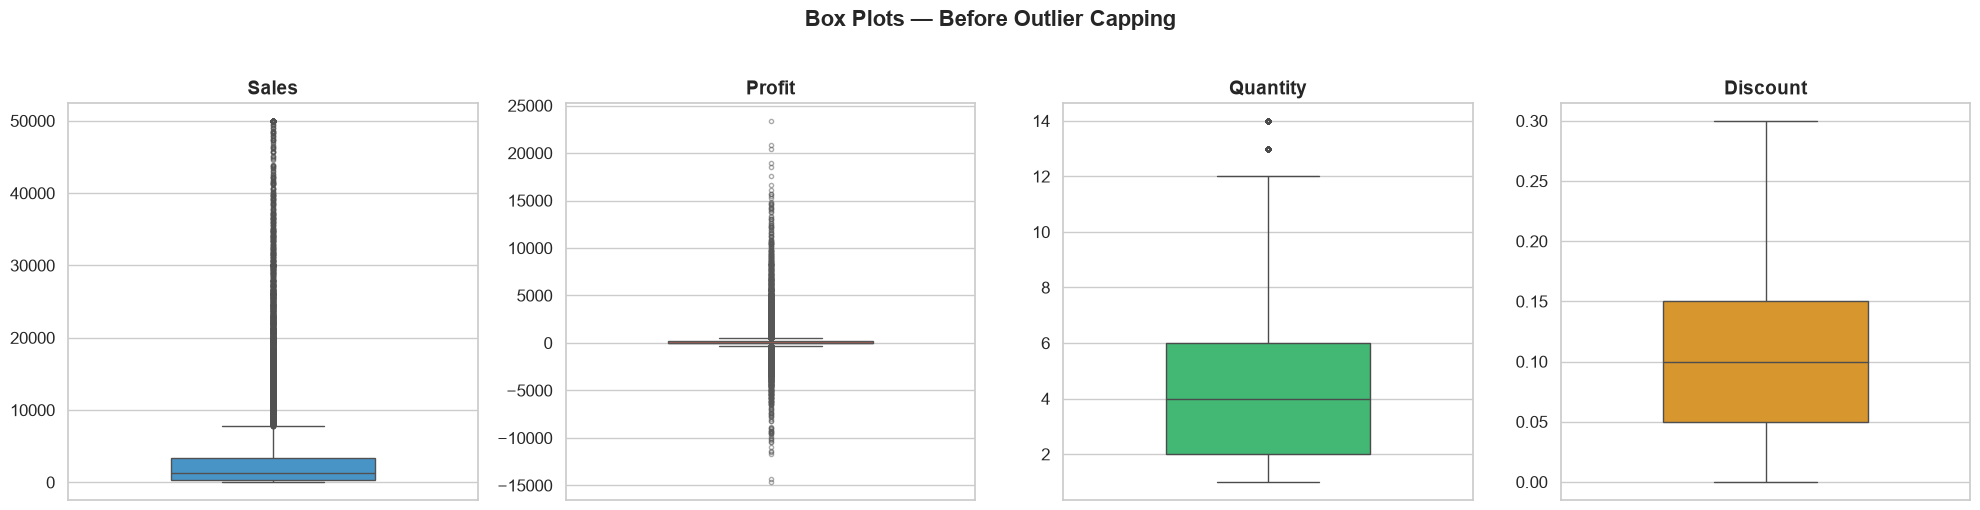

✅ Saved: 01_outliers_before.png


In [14]:
# --- 4a. Visualize outliers with box plots (before capping) ---

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=colors[i], width=0.5,
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('')

plt.suptitle('Box Plots — Before Outlier Capping', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '01_outliers_before.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 01_outliers_before.png')

In [15]:
# --- 4b. Cap outliers using IQR bounds ---

def cap_outliers_iqr(dataframe, column):
    """Cap outliers at IQR bounds instead of removing them."""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    capped = dataframe[column].clip(lower=lower_bound, upper=upper_bound)
    return capped

# Cap outliers for Sales and Profit (keep Quantity and Discount as-is)
for col in ['Sales', 'Profit']:
    df[col] = cap_outliers_iqr(df, col)

print('✅ Outliers capped for Sales and Profit')
print('\nPost-capping statistics:')
df[outlier_cols].describe()

✅ Outliers capped for Sales and Profit

Post-capping statistics:


,Sales,Profit,Quantity,Discount
count,"50,500.00","50,500.00","50,500.00","50,500.00"
mean,"2,280.77",87.56,4.64,0.10
std,"2,500.36",257.08,3.57,0.09
min,50.00,-360.96,1.00,0.00
25%,369.40,-18.45,2.00,0.05
50%,"1,220.39",31.21,4.00,0.10
75%,"3,360.55",209.89,6.00,0.15
max,"7,847.26",552.40,14.00,0.30


---
## 5. Feature Engineering

Creating new derived features to enrich the dataset for deeper analysis:

| Feature | Description |
|---|---|
| `Month`, `Year`, `Quarter`, `Day_of_Week` | Temporal features from Order Date |
| `Month_Name`, `Day_Name` | Human-readable time labels |
| `Profit_Margin_Pct` | Profit ÷ Sales × 100 |
| `Revenue_Per_Unit` | Sales ÷ Quantity |
| `Order_Size` | Bucketed: Small / Medium / Large / Bulk |
| `Is_Profitable` | Boolean: Profit > 0 |

In [16]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================

# --- 5a. Temporal features ---
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Day_of_Week'] = df['Order Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Month_Name'] = df['Order Date'].dt.strftime('%b')  # Jan, Feb, ...
df['Day_Name'] = df['Order Date'].dt.strftime('%a')    # Mon, Tue, ...

# --- 5b. Financial features ---
# Profit Margin (%) - handle division by zero
df['Profit_Margin_Pct'] = np.where(
    df['Sales'] != 0,
    (df['Profit'] / df['Sales']) * 100,
    0
)

# Revenue per unit
df['Revenue_Per_Unit'] = np.where(
    df['Quantity'] != 0,
    df['Sales'] / df['Quantity'],
    0
)

# --- 5c. Order size bucketing ---
def categorize_order_size(qty):
    """Categorize order quantity into size buckets."""
    if qty <= 2:
        return 'Small'
    elif qty <= 5:
        return 'Medium'
    elif qty <= 9:
        return 'Large'
    else:
        return 'Bulk'

df['Order_Size'] = df['Quantity'].apply(categorize_order_size)

# --- 5d. Profitability flag ---
df['Is_Profitable'] = df['Profit'] > 0

# Display new features
print('✅ Feature engineering complete!')
print(f'   New columns: Year, Month, Quarter, Day_of_Week, Month_Name, Day_Name,')
print(f'                Profit_Margin_Pct, Revenue_Per_Unit, Order_Size, Is_Profitable')
print(f'   Total columns: {len(df.columns)}')
print(f'\n--- Sample of engineered features ---')
df[['Order Date', 'Year', 'Month', 'Quarter', 'Month_Name', 'Day_Name',
    'Sales', 'Profit', 'Profit_Margin_Pct', 'Quantity', 'Revenue_Per_Unit',
    'Order_Size', 'Is_Profitable']].head(10)

✅ Feature engineering complete!
   New columns: Year, Month, Quarter, Day_of_Week, Month_Name, Day_Name,
                Profit_Margin_Pct, Revenue_Per_Unit, Order_Size, Is_Profitable
   Total columns: 26

--- Sample of engineered features ---


,Order Date,Year,Month,Quarter,Month_Name,Day_Name,Sales,Profit,Profit_Margin_Pct,Quantity,Revenue_Per_Unit,Order_Size,Is_Profitable
0,2021-08-16,2021,8,3,Aug,Mon,594.74,63.88,10.74,1,594.74,Small,True
1,2023-01-19,2023,1,1,Jan,Thu,102.38,15.10,14.75,9,11.38,Large,True
2,2024-12-14,2024,12,4,Dec,Sat,832.70,39.65,4.76,13,64.05,Bulk,True
3,2022-02-24,2022,2,1,Feb,Thu,"1,400.56",198.50,14.17,5,280.11,Medium,True
4,2021-08-21,2021,8,3,Aug,Sat,99.45,29.31,29.47,13,7.65,Bulk,True
5,2024-04-03,2024,4,2,Apr,Wed,109.90,-0.06,-0.05,12,9.16,Bulk,False
6,2022-04-07,2022,4,2,Apr,Thu,"7,847.26",552.40,7.04,5,"1,569.45",Medium,True
7,2024-10-25,2024,10,4,Oct,Fri,"3,875.25",216.28,5.58,1,"3,875.25",Small,True
8,2023-02-03,2023,2,1,Feb,Fri,659.13,-181.26,-27.50,1,659.13,Small,False
9,2023-08-21,2023,8,3,Aug,Mon,583.74,-50.09,-8.58,3,194.58,Medium,False


---
## 6. KPI Dashboard Cards

Key Performance Indicators at a glance:
- **Total Sales** — Overall revenue generated
- **Total Profit** — Net profit across all orders
- **Average Order Value (AOV)** — Mean sales per order
- **Total Customers** — Unique customer count

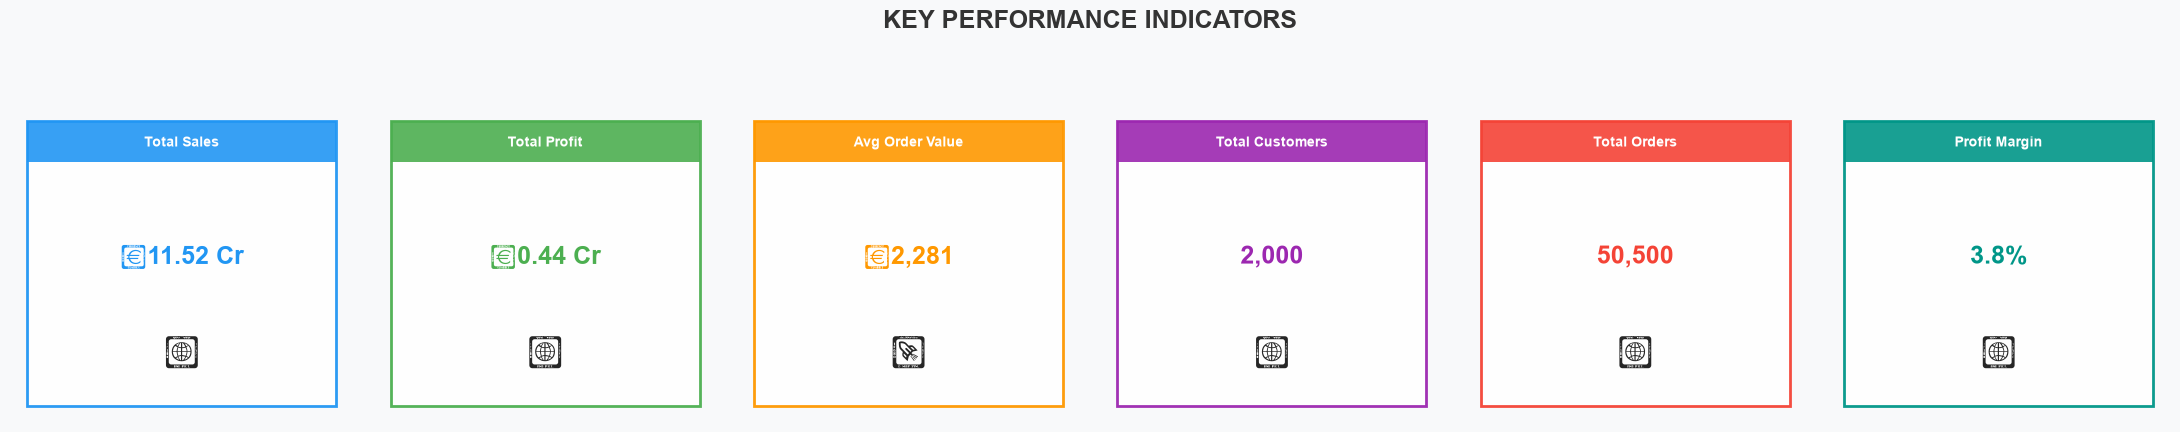

✅ Saved: 02_kpi_cards.png


In [17]:
# ============================================================
# 6. KPI DASHBOARD CARDS
# ============================================================

# Calculate KPIs
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_order_value = df['Sales'].mean()
total_customers = df['Customer ID'].nunique()
total_orders = df['Order ID'].nunique()
profit_margin_overall = (total_profit / total_sales) * 100

# KPI data
kpis = [
    ('Total Sales',         f'₹{total_sales/1e7:,.2f} Cr',   '#2196F3', '💰'),
    ('Total Profit',        f'₹{total_profit/1e7:,.2f} Cr',   '#4CAF50', '📈'),
    ('Avg Order Value',     f'₹{avg_order_value:,.0f}',        '#FF9800', '🛒'),
    ('Total Customers',     f'{total_customers:,}',             '#9C27B0', '👥'),
    ('Total Orders',        f'{total_orders:,}',                '#F44336', '📦'),
    ('Profit Margin',       f'{profit_margin_overall:.1f}%',    '#009688', '🎯'),
]

# Create professional KPI card figure
fig, axes = plt.subplots(1, 6, figsize=(22, 4))
fig.patch.set_facecolor('#f8f9fa')

for i, (title, value, color, emoji) in enumerate(kpis):
    ax = axes[i]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Card background
    card = plt.Rectangle((0.05, 0.05), 0.9, 0.9, linewidth=2,
                          edgecolor=color, facecolor='white',
                          transform=ax.transAxes, zorder=1,
                          alpha=0.95)
    card.set_clip_on(False)
    ax.add_patch(card)

    # Top color bar
    bar = plt.Rectangle((0.05, 0.82), 0.9, 0.13, linewidth=0,
                         facecolor=color, transform=ax.transAxes, zorder=2,
                         alpha=0.9)
    ax.add_patch(bar)

    # Text
    ax.text(0.5, 0.88, title, transform=ax.transAxes, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white', zorder=3)
    ax.text(0.5, 0.52, value, transform=ax.transAxes, ha='center', va='center',
            fontsize=18, fontweight='bold', color=color, zorder=3)
    ax.text(0.5, 0.22, emoji, transform=ax.transAxes, ha='center', va='center',
            fontsize=24, zorder=3)

plt.suptitle('KEY PERFORMANCE INDICATORS', fontsize=18, fontweight='bold',
             y=1.08, color='#333333')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '02_kpi_cards.png'), bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Saved: 02_kpi_cards.png')

---
## 7. Professional Visualizations & Business Questions

17 charts answering key business questions across sales, profit, customers, products, and trends.

### 7.1 Best Selling Products (by Revenue)

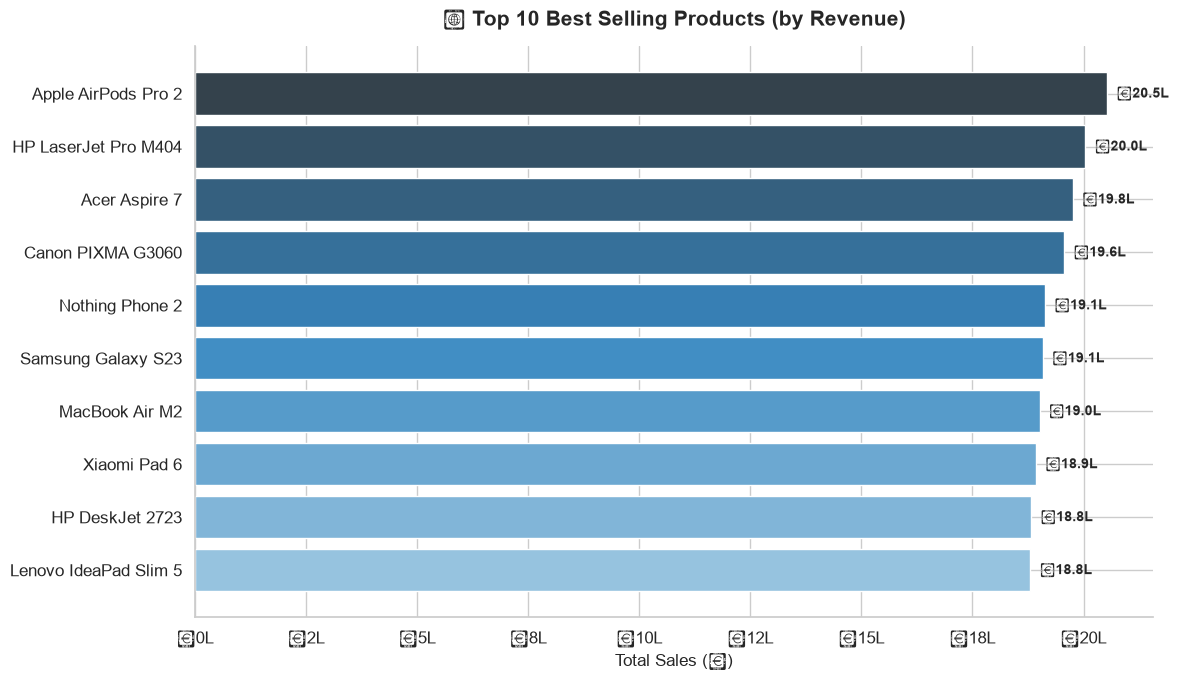

✅ Saved: 03_top_products_revenue.png


In [18]:
# ============================================================
# CHART 1: Top 10 Best Selling Products (by Revenue)
# ============================================================

top_products_revenue = df.groupby('Product Name')['Sales'].sum().nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
colors_gradient = sns.color_palette('Blues_d', n_colors=10)
bars = ax.barh(top_products_revenue.index, top_products_revenue.values, color=colors_gradient)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + top_products_revenue.max() * 0.01, bar.get_y() + bar.get_height()/2,
            f'₹{width/1e5:,.1f}L', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Total Sales (₹)', fontsize=12)
ax.set_title('🏆 Top 10 Best Selling Products (by Revenue)', fontsize=15, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '03_top_products_revenue.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 03_top_products_revenue.png')

### 7.2 Best Selling Products (by Quantity)

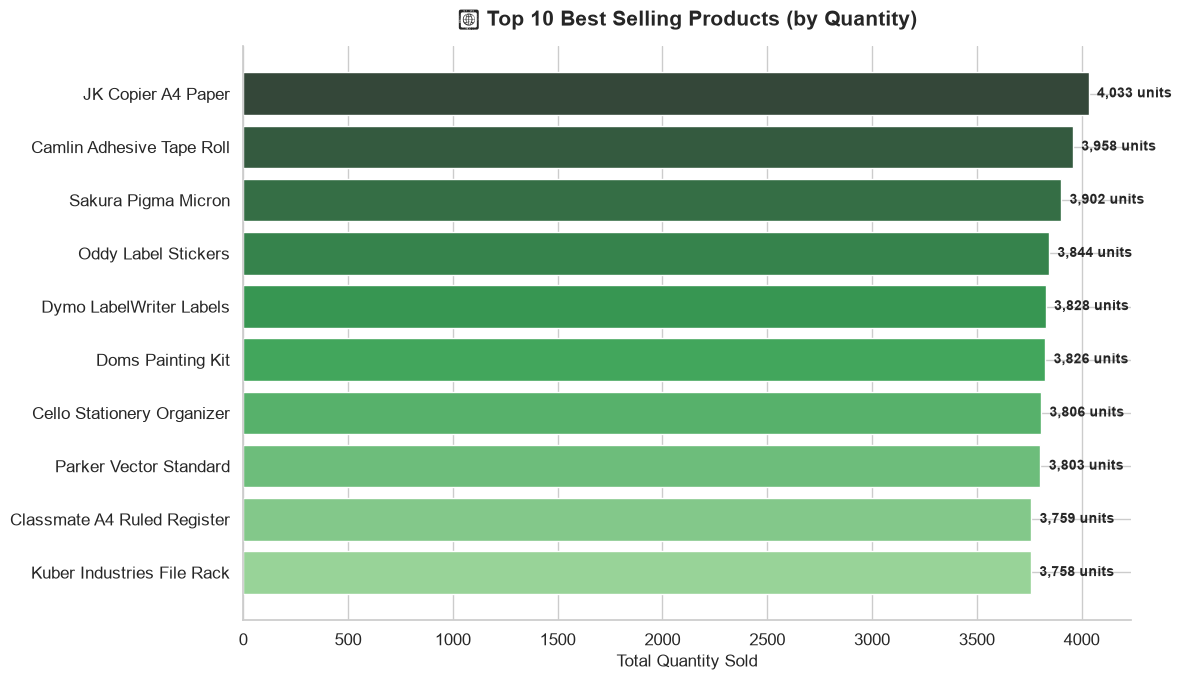

✅ Saved: 04_top_products_quantity.png


In [19]:
# ============================================================
# CHART 2: Top 10 Best Selling Products (by Quantity)
# ============================================================

top_products_qty = df.groupby('Product Name')['Quantity'].sum().nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
colors_gradient = sns.color_palette('Greens_d', n_colors=10)
bars = ax.barh(top_products_qty.index, top_products_qty.values, color=colors_gradient)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + top_products_qty.max() * 0.01, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f} units', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Total Quantity Sold', fontsize=12)
ax.set_title('📦 Top 10 Best Selling Products (by Quantity)', fontsize=15, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '04_top_products_quantity.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 04_top_products_quantity.png')

### 7.3 Highest Profit Category

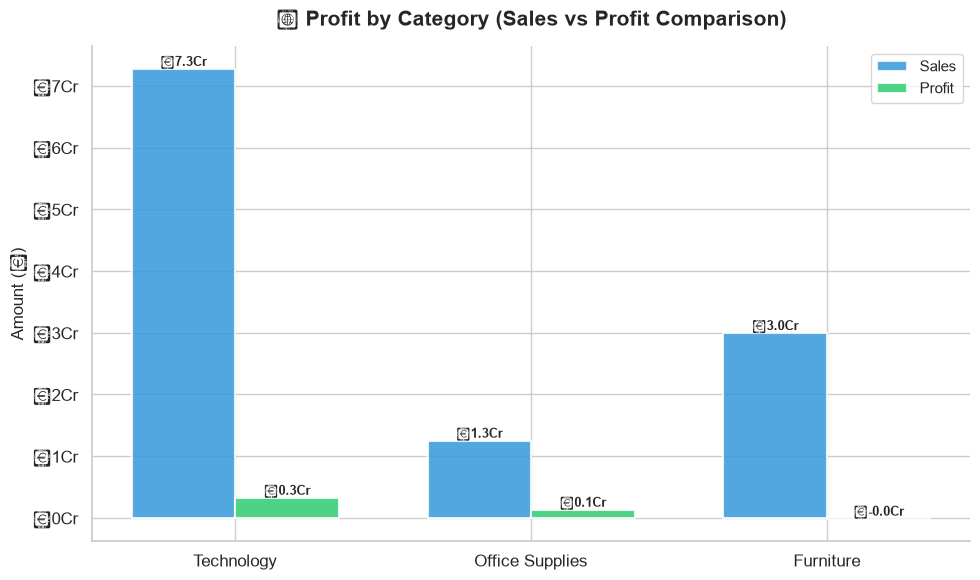

✅ Saved: 05_profit_by_category.png


In [20]:
# ============================================================
# CHART 3: Profit by Category
# ============================================================

cat_profit = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(cat_profit))

bars1 = ax.bar(x - bar_width/2, cat_profit['Sales'], bar_width, label='Sales',
               color='#3498db', alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + bar_width/2, cat_profit['Profit'], bar_width, label='Profit',
               color='#2ecc71', alpha=0.85, edgecolor='white', linewidth=1.5)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'₹{bar.get_height()/1e7:.1f}Cr', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'₹{bar.get_height()/1e7:.1f}Cr', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(cat_profit.index, fontsize=12)
ax.set_ylabel('Amount (₹)', fontsize=12)
ax.set_title('📊 Profit by Category (Sales vs Profit Comparison)', fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e7:.0f}Cr'))

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '05_profit_by_category.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 05_profit_by_category.png')

### 7.4 Monthly Sales Trend (Multi-Year)

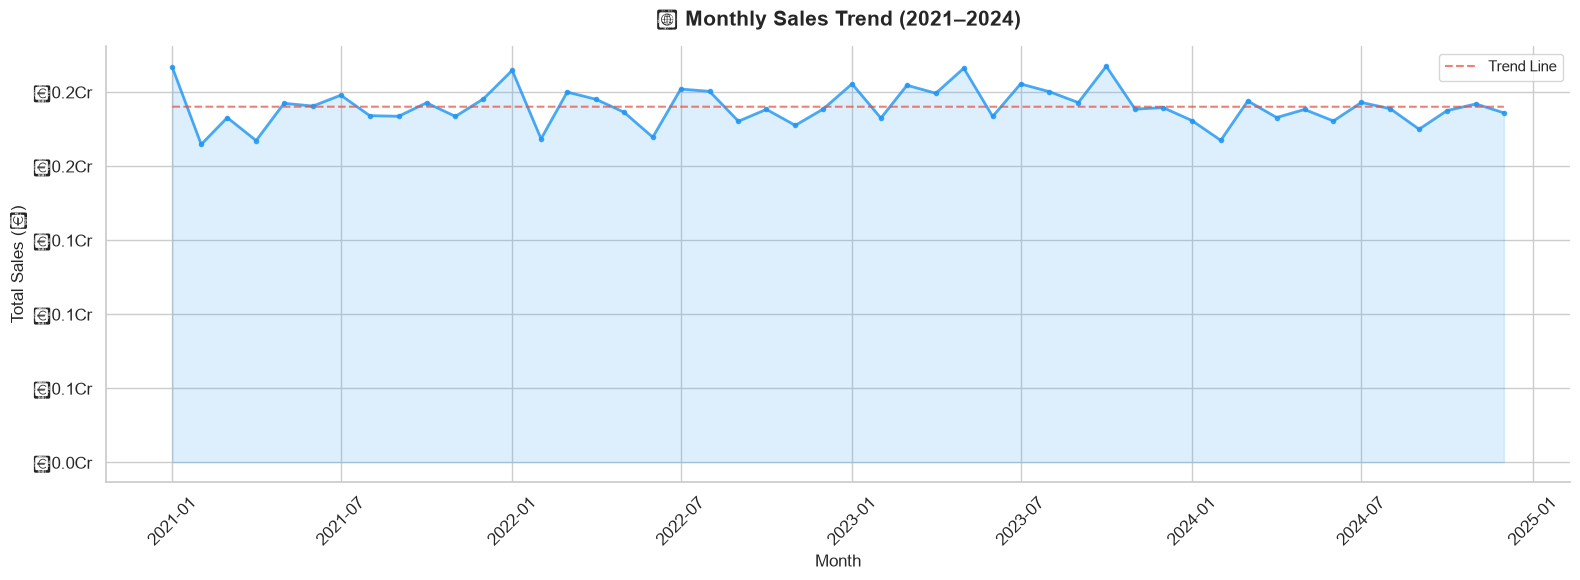

✅ Saved: 06_monthly_sales_trend.png


In [21]:
# ============================================================
# CHART 4: Monthly Sales Trend (Multi-Year)
# ============================================================

monthly_sales = df.groupby([df['Order Date'].dt.to_period('M')])['Sales'].sum().reset_index()
monthly_sales.columns = ['Month', 'Sales']
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(monthly_sales['Month'], monthly_sales['Sales'], color='#2196F3',
        linewidth=2, marker='o', markersize=3, alpha=0.8)
ax.fill_between(monthly_sales['Month'], monthly_sales['Sales'], alpha=0.15, color='#2196F3')

# Add trend line
z = np.polyfit(range(len(monthly_sales)), monthly_sales['Sales'], 1)
p = np.poly1d(z)
ax.plot(monthly_sales['Month'], p(range(len(monthly_sales))),
        '--', color='#e74c3c', linewidth=1.5, alpha=0.7, label='Trend Line')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Sales (₹)', fontsize=12)
ax.set_title('📈 Monthly Sales Trend (2021–2024)', fontsize=15, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e7:.1f}Cr'))
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '06_monthly_sales_trend.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 06_monthly_sales_trend.png')

### 7.5 State-wise Sales (Top 15)

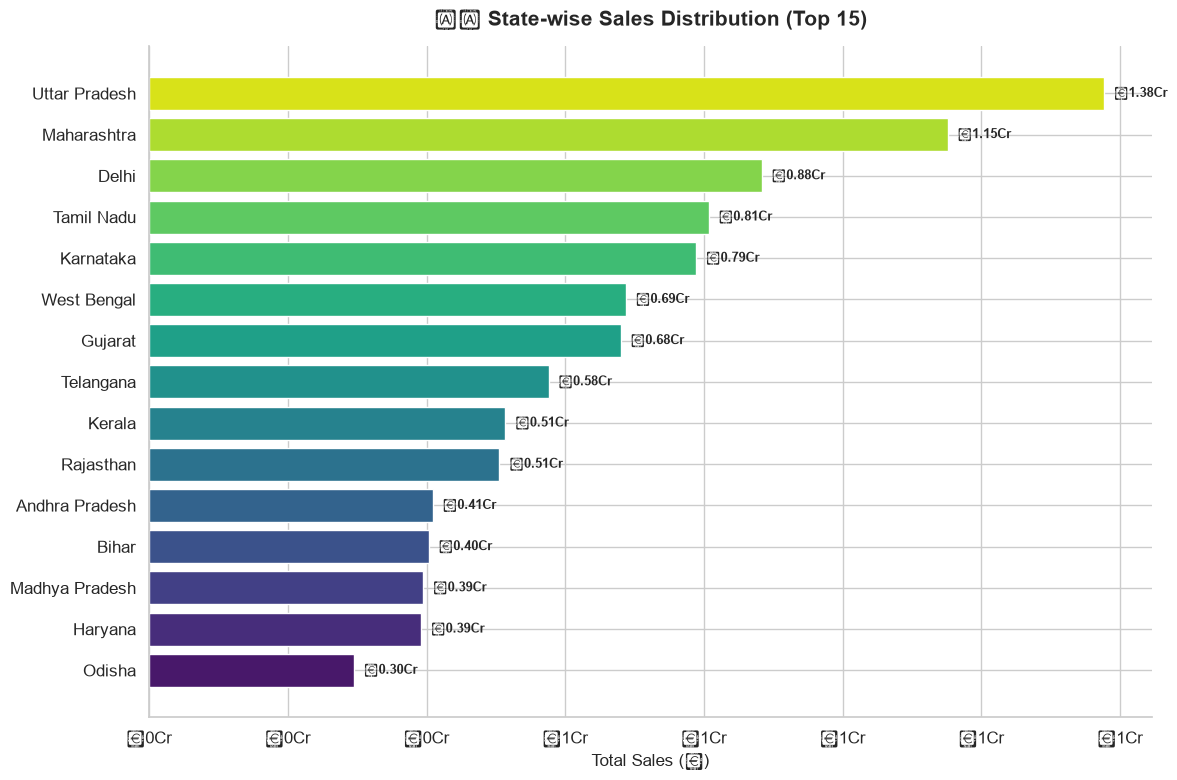

✅ Saved: 07_statewise_sales.png


In [22]:
# ============================================================
# CHART 5: State-wise Sales (Top 15)
# ============================================================

state_sales = df.groupby('State')['Sales'].sum().nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette('viridis', n_colors=15)
bars = ax.barh(state_sales.index, state_sales.values, color=colors)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + state_sales.max() * 0.01, bar.get_y() + bar.get_height()/2,
            f'₹{width/1e7:.2f}Cr', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Total Sales (₹)', fontsize=12)
ax.set_title('🇮🇳 State-wise Sales Distribution (Top 15)', fontsize=15, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e7:.0f}Cr'))

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '07_statewise_sales.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 07_statewise_sales.png')

### 7.6 Region-wise Profit (Donut Chart)

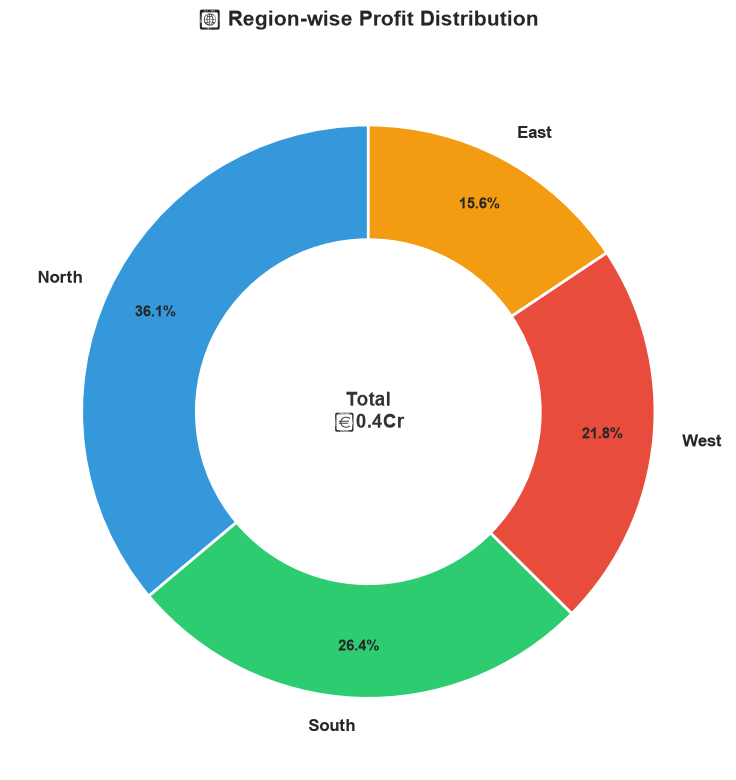

✅ Saved: 08_regionwise_profit.png


In [23]:
# ============================================================
# CHART 6: Region-wise Profit (Donut Chart)
# ============================================================

region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
colors_region = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    region_profit.values, labels=region_profit.index, colors=colors_region,
    autopct='%1.1f%%', startangle=90, pctdistance=0.82,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Center text
ax.text(0, 0, f'Total\n₹{region_profit.sum()/1e7:.1f}Cr',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#333')

ax.set_title('🌍 Region-wise Profit Distribution', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '08_regionwise_profit.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 08_regionwise_profit.png')

### 7.7 Top 10 Customers by Revenue

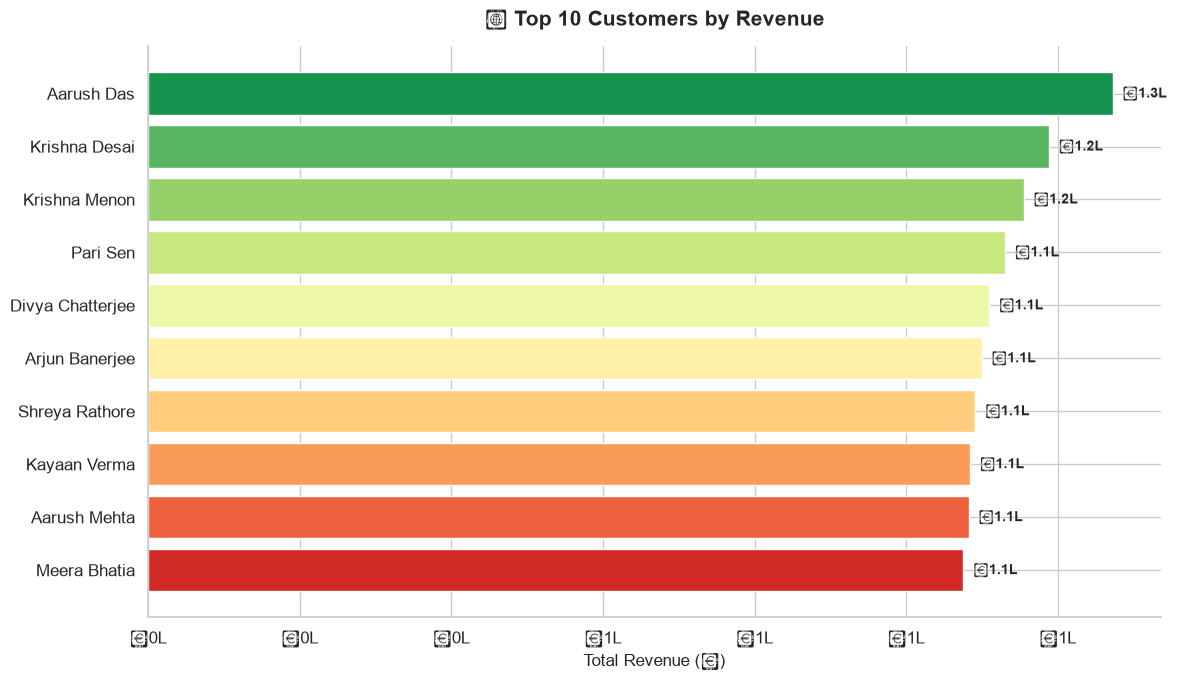

✅ Saved: 09_top_customers.png


In [24]:
# ============================================================
# CHART 7: Top 10 Customers by Revenue
# ============================================================

top_customers = df.groupby('Customer Name')['Sales'].sum().nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
colors_cust = sns.color_palette('RdYlGn', n_colors=10)
bars = ax.barh(top_customers.index, top_customers.values, color=colors_cust)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + top_customers.max() * 0.01, bar.get_y() + bar.get_height()/2,
            f'₹{width/1e5:,.1f}L', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Total Revenue (₹)', fontsize=12)
ax.set_title('👑 Top 10 Customers by Revenue', fontsize=15, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '09_top_customers.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 09_top_customers.png')

### 7.8 Top 10 Loss-Making Products

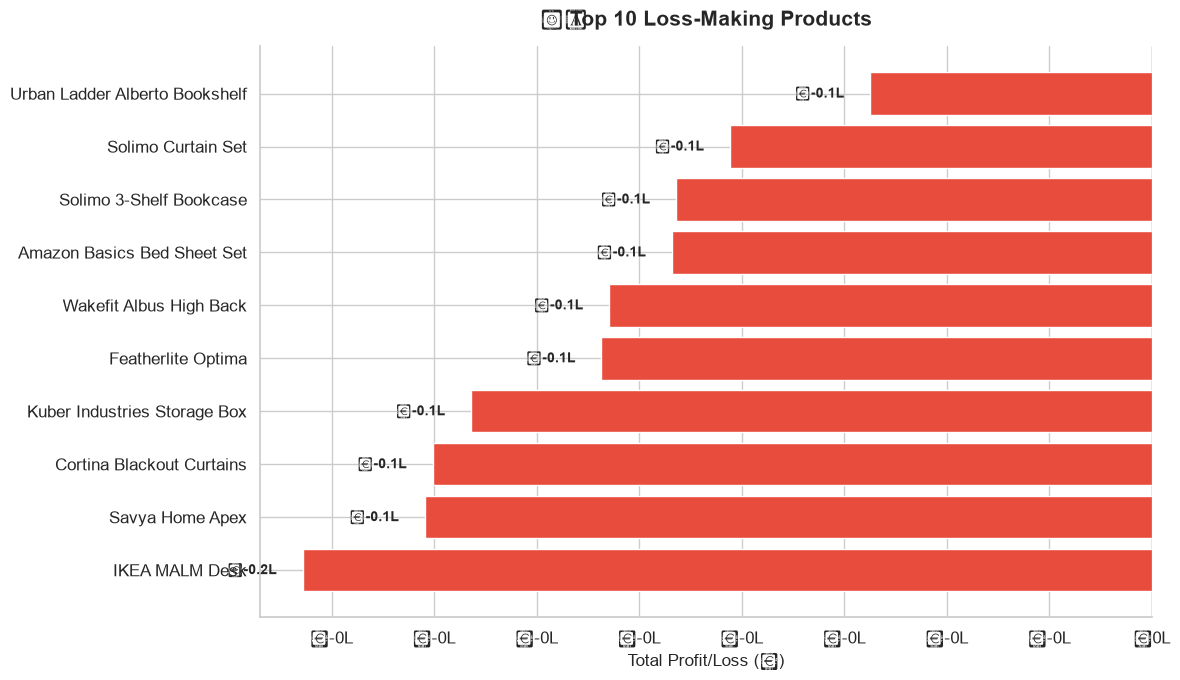

✅ Saved: 10_loss_making_products.png


In [25]:
# ============================================================
# CHART 8: Top 10 Loss-Making Products
# ============================================================

loss_products = df.groupby('Product Name')['Profit'].sum().nsmallest(10).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors_loss = ['#e74c3c' if v < 0 else '#2ecc71' for v in loss_products.values]
bars = ax.barh(loss_products.index, loss_products.values, color=colors_loss)

# Add value labels
for bar in bars:
    width = bar.get_width()
    label_x = width - abs(loss_products.min()) * 0.03 if width < 0 else width + abs(loss_products.min()) * 0.01
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f'₹{width/1e5:,.1f}L', va='center', fontsize=10,
            fontweight='bold', ha='right' if width < 0 else 'left')

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Total Profit/Loss (₹)', fontsize=12)
ax.set_title('⚠️ Top 10 Loss-Making Products', fontsize=15, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '10_loss_making_products.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 10_loss_making_products.png')

### 7.9 Sales vs Profit (Scatter Plot)

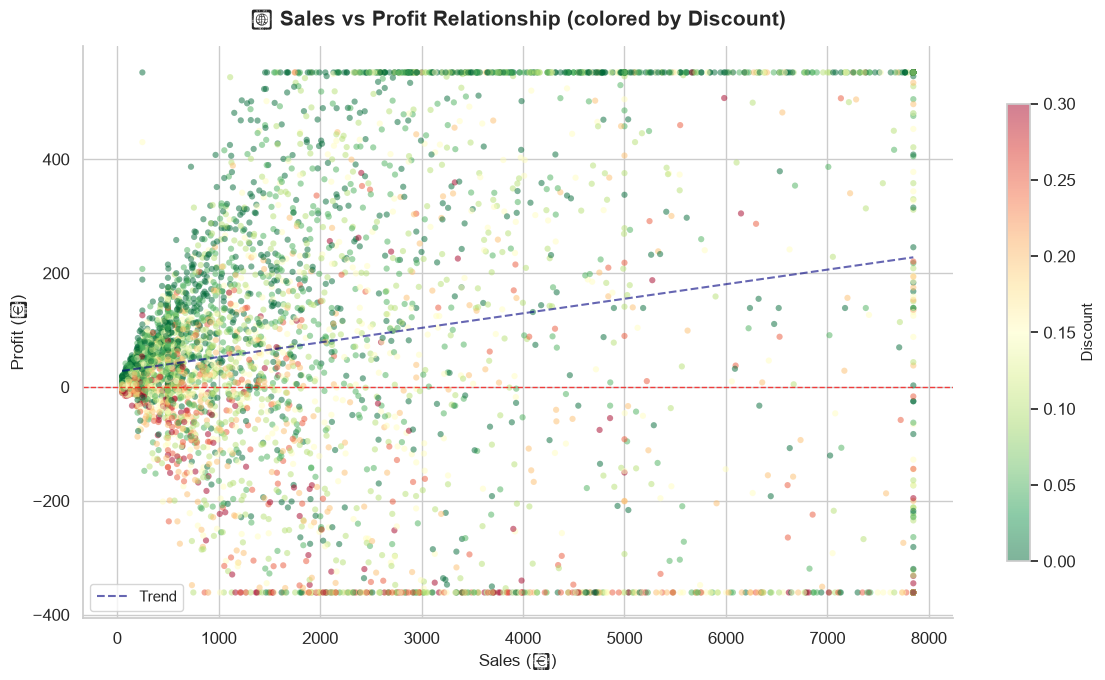

✅ Saved: 11_sales_vs_profit.png


In [26]:
# ============================================================
# CHART 9: Sales vs Profit (Scatter Plot)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

# Sample for better visualization (avoid overplotting)
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

scatter = ax.scatter(sample_df['Sales'], sample_df['Profit'],
                     c=sample_df['Discount'], cmap='RdYlGn_r',
                     alpha=0.5, s=20, edgecolors='none')

# Add colorbar for discount
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('Discount', fontsize=11)

# Reference line at profit = 0
ax.axhline(y=0, color='red', linewidth=1, linestyle='--', alpha=0.7)

# Trend line
z = np.polyfit(sample_df['Sales'], sample_df['Profit'], 1)
p = np.poly1d(z)
xs = np.linspace(sample_df['Sales'].min(), sample_df['Sales'].max(), 100)
ax.plot(xs, p(xs), '--', color='navy', linewidth=1.5, alpha=0.6, label='Trend')

ax.set_xlabel('Sales (₹)', fontsize=12)
ax.set_ylabel('Profit (₹)', fontsize=12)
ax.set_title('💡 Sales vs Profit Relationship (colored by Discount)', fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '11_sales_vs_profit.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 11_sales_vs_profit.png')

### 7.10 Discount Impact on Profit

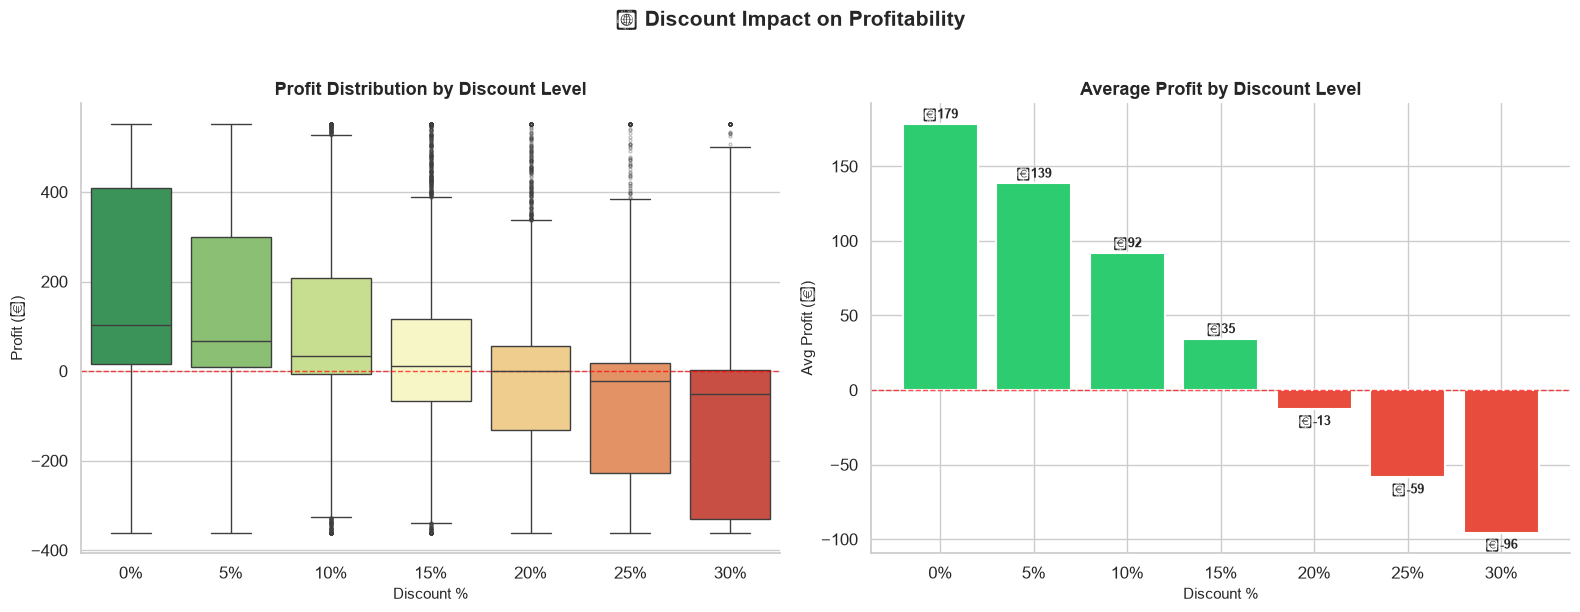

✅ Saved: 12_discount_impact.png


In [27]:
# ============================================================
# CHART 10: Discount Impact on Profit
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Box plot of profit by discount level
df['Discount_Pct'] = (df['Discount'] * 100).astype(int).astype(str) + '%'

sns.boxplot(data=df, x='Discount_Pct', y='Profit', ax=axes[0],
            palette='RdYlGn_r',
            order=[f'{int(d*100)}%' for d in sorted(df['Discount'].unique())],
            flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
axes[0].axhline(y=0, color='red', linewidth=1, linestyle='--', alpha=0.7)
axes[0].set_title('Profit Distribution by Discount Level', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Discount %', fontsize=11)
axes[0].set_ylabel('Profit (₹)', fontsize=11)

# Right: Average profit by discount level (bar chart)
avg_profit_by_discount = df.groupby('Discount')['Profit'].mean()
colors_disc = ['#2ecc71' if v > 0 else '#e74c3c' for v in avg_profit_by_discount.values]
axes[1].bar([f'{int(d*100)}%' for d in avg_profit_by_discount.index],
            avg_profit_by_discount.values, color=colors_disc, edgecolor='white', linewidth=1.5)
axes[1].axhline(y=0, color='red', linewidth=1, linestyle='--', alpha=0.7)
axes[1].set_title('Average Profit by Discount Level', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Discount %', fontsize=11)
axes[1].set_ylabel('Avg Profit (₹)', fontsize=11)

for i, (d, v) in enumerate(avg_profit_by_discount.items()):
    axes[1].text(i, v + (avg_profit_by_discount.max() * 0.02 if v > 0 else -avg_profit_by_discount.max() * 0.06),
                f'₹{v:,.0f}', ha='center', fontsize=9, fontweight='bold')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('🎯 Discount Impact on Profitability', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '12_discount_impact.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 12_discount_impact.png')

### 7.11 Category Contribution to Sales (Donut Chart)

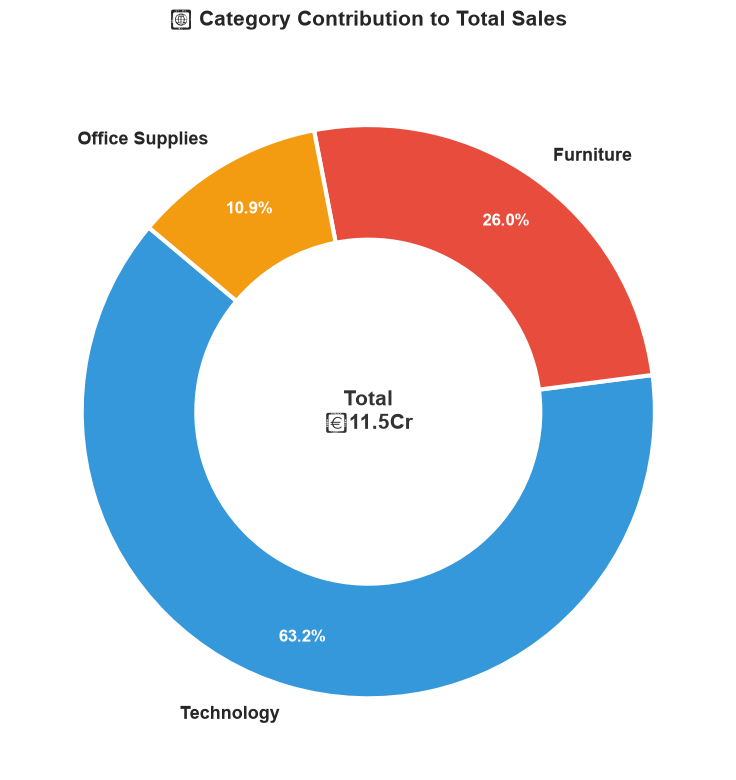

✅ Saved: 13_category_contribution.png


In [28]:
# ============================================================
# CHART 11: Category Contribution to Sales (Donut Chart)
# ============================================================

cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
colors_cat = ['#3498db', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    cat_sales.values, labels=cat_sales.index, colors=colors_cat,
    autopct='%1.1f%%', startangle=140, pctdistance=0.82,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=3),
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.text(0, 0, f'Total\n₹{cat_sales.sum()/1e7:.1f}Cr',
        ha='center', va='center', fontsize=15, fontweight='bold', color='#333')

ax.set_title('🎪 Category Contribution to Total Sales', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '13_category_contribution.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 13_category_contribution.png')

### 7.12 Sub-Category Profitability Heatmap

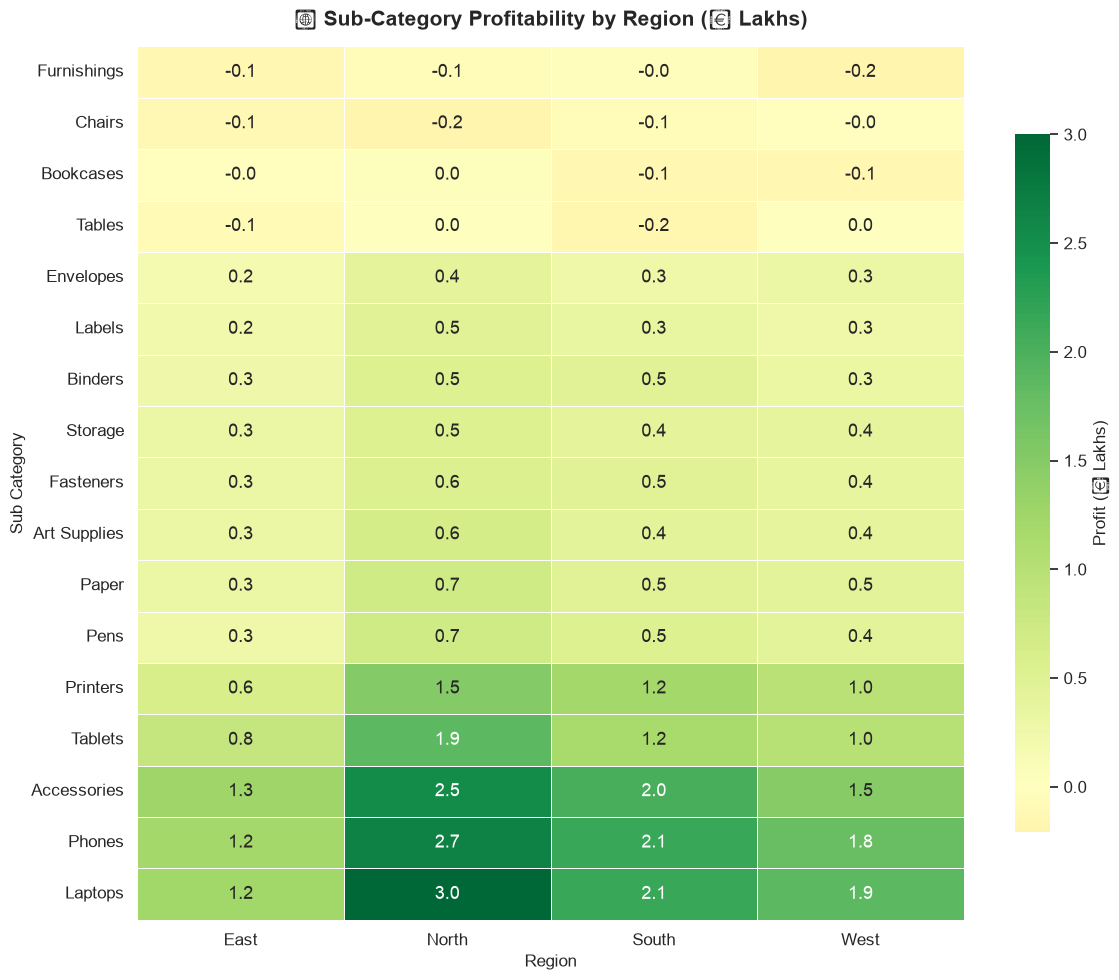

✅ Saved: 14_subcategory_heatmap.png


In [29]:
# ============================================================
# CHART 12: Sub-Category Profitability Heatmap
# ============================================================

# Create pivot: Sub Category vs Region for Profit
subcat_region_profit = df.pivot_table(
    values='Profit', index='Sub Category', columns='Region', aggfunc='sum'
).fillna(0)

# Sort by total profit
subcat_region_profit['Total'] = subcat_region_profit.sum(axis=1)
subcat_region_profit = subcat_region_profit.sort_values('Total', ascending=True)
subcat_region_profit = subcat_region_profit.drop('Total', axis=1)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(subcat_region_profit / 1e5, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Profit (₹ Lakhs)', 'shrink': 0.8},
            ax=ax)

ax.set_title('📊 Sub-Category Profitability by Region (₹ Lakhs)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Sub Category', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '14_subcategory_heatmap.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 14_subcategory_heatmap.png')

### 7.13 Quarterly Revenue Trend (Stacked Bar)

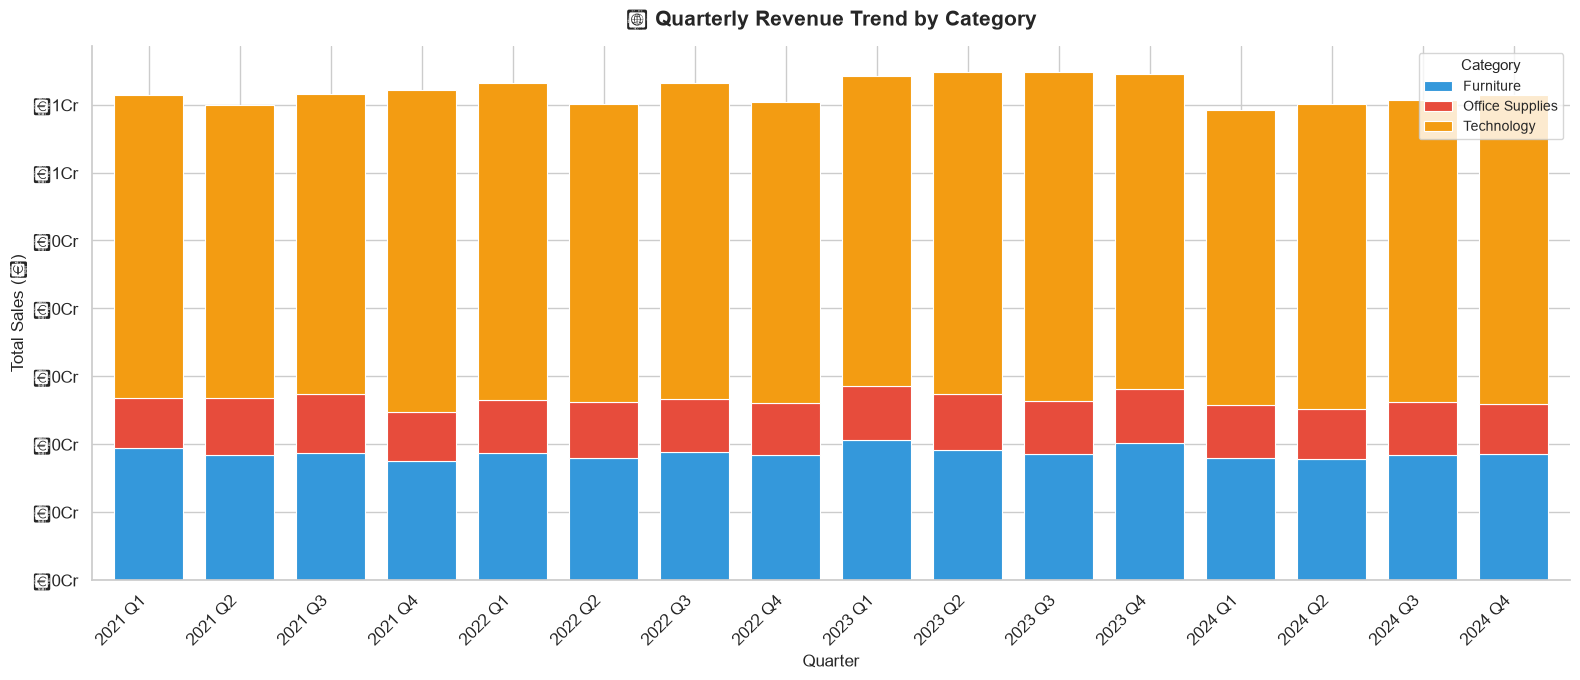

✅ Saved: 15_quarterly_revenue.png


In [30]:
# ============================================================
# CHART 13: Quarterly Revenue Trend (Stacked Bar by Category)
# ============================================================

quarterly_cat = df.pivot_table(
    values='Sales', index=['Year', 'Quarter'], columns='Category', aggfunc='sum'
).fillna(0)

# Create quarter labels
quarterly_cat.index = [f'{y} Q{q}' for y, q in quarterly_cat.index]

fig, ax = plt.subplots(figsize=(16, 7))
colors_stack = ['#3498db', '#e74c3c', '#f39c12']
quarterly_cat.plot(kind='bar', stacked=True, ax=ax, color=colors_stack,
                   edgecolor='white', linewidth=0.8, width=0.75)

ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('Total Sales (₹)', fontsize=12)
ax.set_title('📅 Quarterly Revenue Trend by Category', fontsize=15, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e7:.0f}Cr'))
ax.legend(title='Category', fontsize=10, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '15_quarterly_revenue.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 15_quarterly_revenue.png')

### 7.14 Payment Mode Distribution

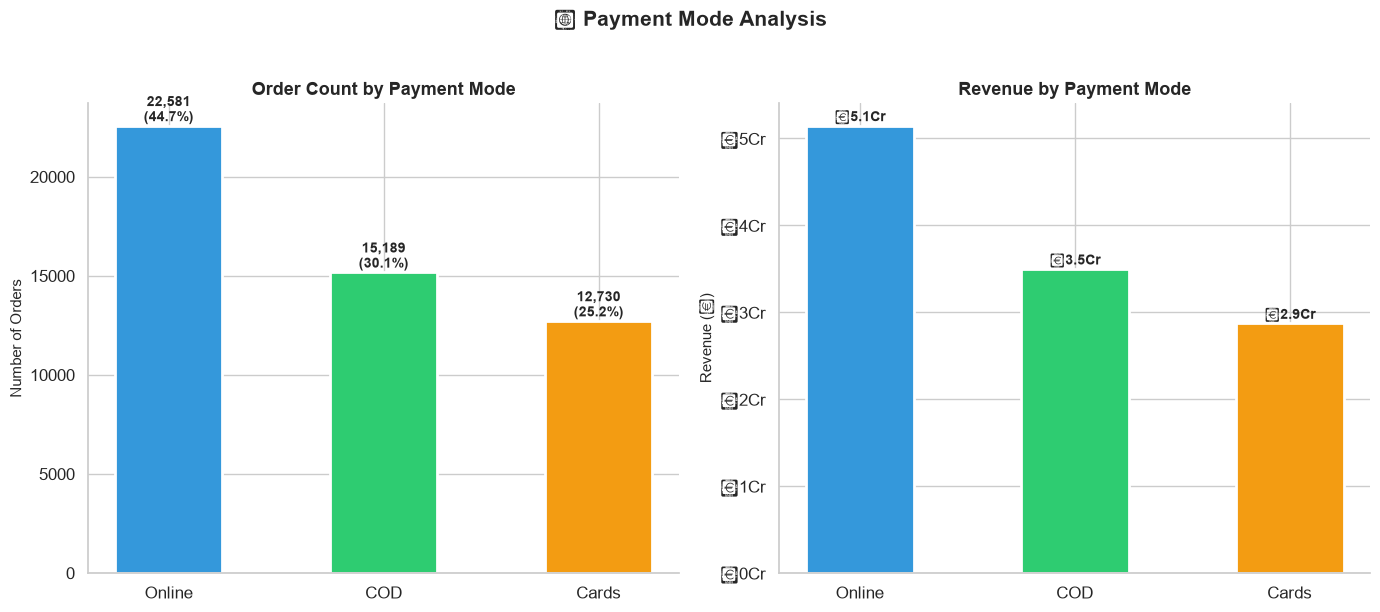

✅ Saved: 16_payment_mode.png


In [31]:
# ============================================================
# CHART 14: Payment Mode Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Count plot
payment_counts = df['Payment Mode'].value_counts()
colors_pay = ['#3498db', '#2ecc71', '#f39c12']
axes[0].bar(payment_counts.index, payment_counts.values, color=colors_pay,
            edgecolor='white', linewidth=2, width=0.5)
for i, (mode, count) in enumerate(payment_counts.items()):
    axes[0].text(i, count + payment_counts.max() * 0.01,
                f'{count:,}\n({count/len(df)*100:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Order Count by Payment Mode', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Orders', fontsize=11)
axes[0].spines[['top', 'right']].set_visible(False)

# Right: Revenue by payment mode
payment_revenue = df.groupby('Payment Mode')['Sales'].sum().sort_values(ascending=False)
axes[1].bar(payment_revenue.index, payment_revenue.values, color=colors_pay,
            edgecolor='white', linewidth=2, width=0.5)
for i, (mode, rev) in enumerate(payment_revenue.items()):
    axes[1].text(i, rev + payment_revenue.max() * 0.01,
                f'₹{rev/1e7:.1f}Cr', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Revenue by Payment Mode', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Revenue (₹)', fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e7:.0f}Cr'))
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('💳 Payment Mode Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '16_payment_mode.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 16_payment_mode.png')

### 7.15 Ship Mode vs Average Profit

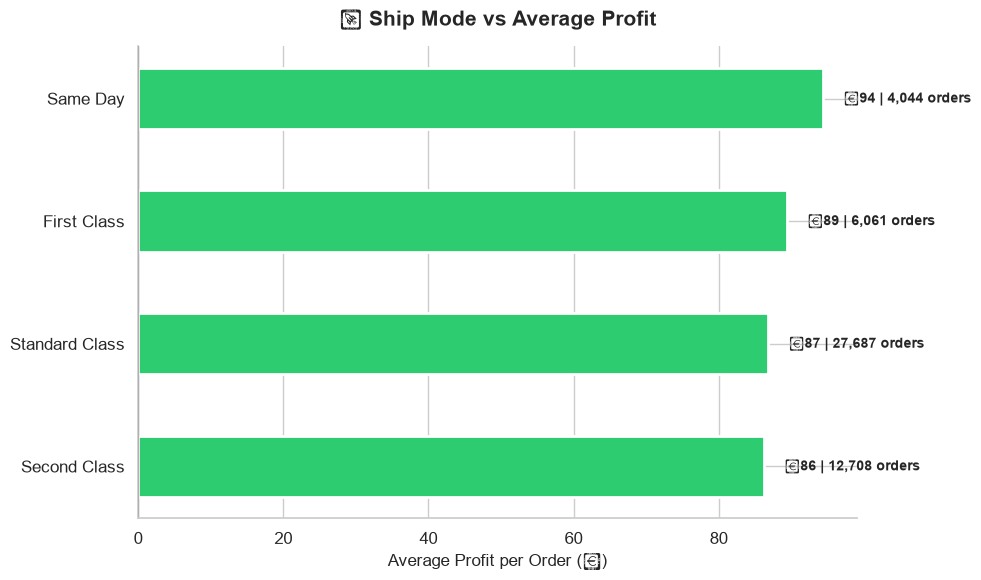

✅ Saved: 17_ship_mode_profit.png


In [32]:
# ============================================================
# CHART 15: Ship Mode vs Average Profit
# ============================================================

ship_analysis = df.groupby('Ship Mode').agg(
    avg_profit=('Profit', 'mean'),
    total_orders=('Order ID', 'count'),
    avg_sales=('Sales', 'mean')
).sort_values('avg_profit', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_ship = ['#e74c3c' if v < 0 else '#2ecc71' for v in ship_analysis['avg_profit']]
bars = ax.barh(ship_analysis.index, ship_analysis['avg_profit'], color=colors_ship,
               edgecolor='white', linewidth=2, height=0.5)

# Add value labels with order counts
for i, (bar, (idx, row)) in enumerate(zip(bars, ship_analysis.iterrows())):
    width = bar.get_width()
    ax.text(width + abs(ship_analysis['avg_profit'].max()) * 0.03,
            bar.get_y() + bar.get_height()/2,
            f'₹{width:,.0f} | {int(row["total_orders"]):,} orders',
            va='center', fontsize=10, fontweight='bold')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Average Profit per Order (₹)', fontsize=12)
ax.set_title('🚚 Ship Mode vs Average Profit', fontsize=15, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '17_ship_mode_profit.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 17_ship_mode_profit.png')

### 7.16 Profit Margin Distribution

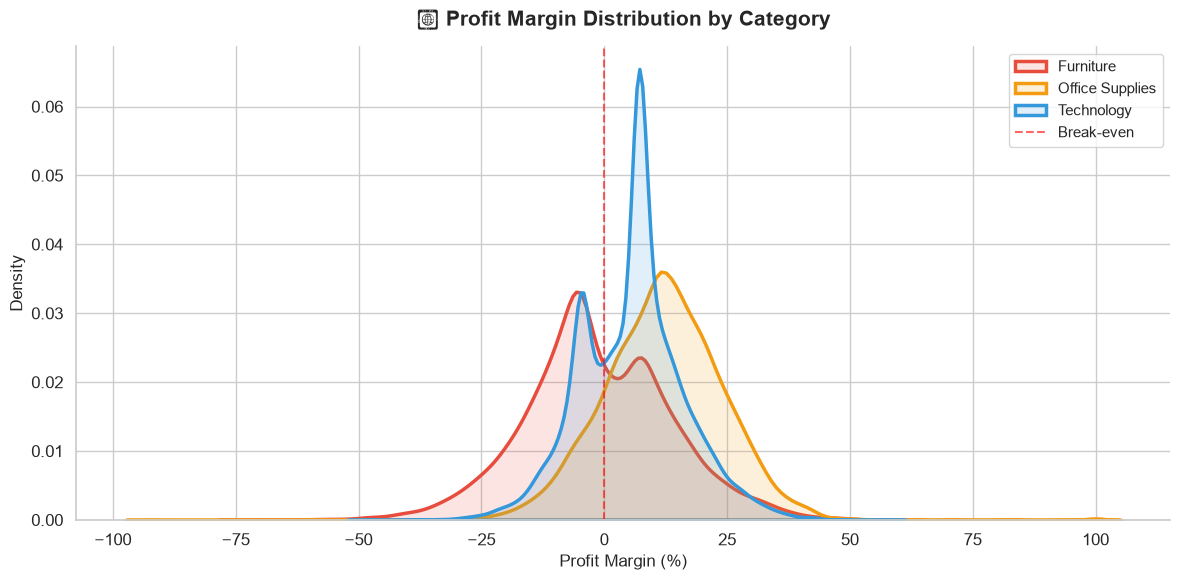

✅ Saved: 18_profit_margin_distribution.png


In [33]:
# ============================================================
# CHART 16: Profit Margin Distribution (by Category)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
colors_kde = {'Technology': '#3498db', 'Furniture': '#e74c3c', 'Office Supplies': '#f39c12'}

for cat in df['Category'].unique():
    subset = df[df['Category'] == cat]['Profit_Margin_Pct']
    # Clip extreme margins for better visualization
    subset = subset.clip(-100, 100)
    sns.kdeplot(subset, ax=ax, label=cat, color=colors_kde.get(cat, '#333'),
                linewidth=2.5, fill=True, alpha=0.15)

ax.axvline(x=0, color='red', linewidth=1.5, linestyle='--', alpha=0.6, label='Break-even')
ax.set_xlabel('Profit Margin (%)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('📊 Profit Margin Distribution by Category', fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '18_profit_margin_distribution.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 18_profit_margin_distribution.png')

### 7.17 Correlation Heatmap

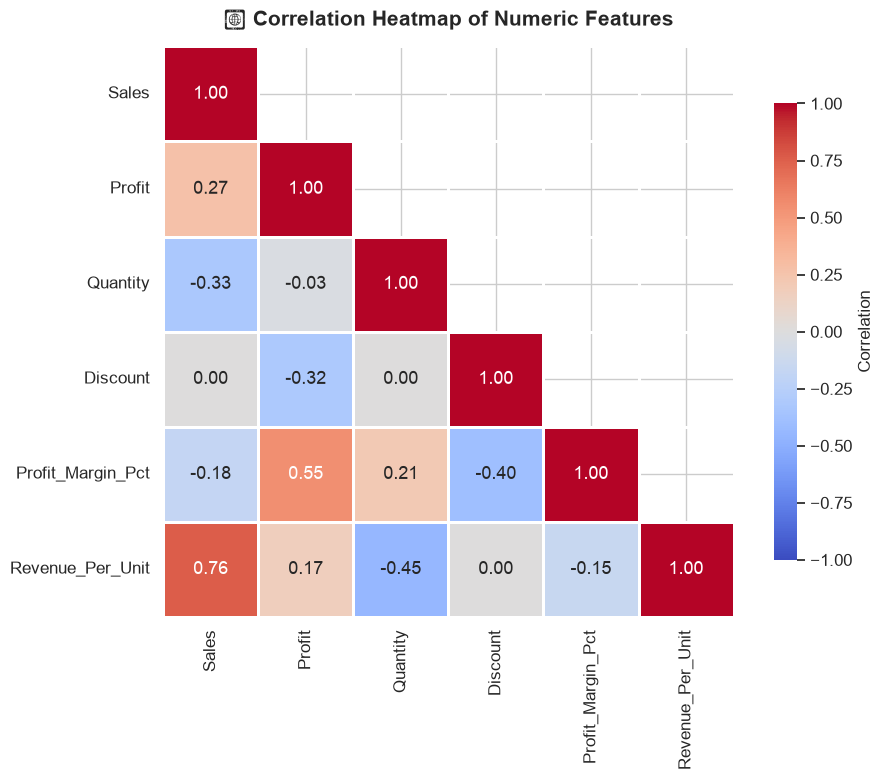

✅ Saved: 19_correlation_heatmap.png


In [34]:
# ============================================================
# CHART 17: Correlation Heatmap
# ============================================================

numeric_df = df[['Sales', 'Profit', 'Quantity', 'Discount',
                 'Profit_Margin_Pct', 'Revenue_Per_Unit']]
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=1, linecolor='white',
            square=True, cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax, vmin=-1, vmax=1)

ax.set_title('🔗 Correlation Heatmap of Numeric Features',
             fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, '19_correlation_heatmap.png'), bbox_inches='tight')
plt.show()
print('✅ Saved: 19_correlation_heatmap.png')

---
## 8. Save Final Cleaned Dataset

In [35]:
# ============================================================
# 8. SAVE FINAL CLEANED & ENRICHED DATASET
# ============================================================

# Save the cleaned and feature-engineered dataset
df.to_csv(os.path.join(DATASET_DIR, 'sales_data_cleaned.csv'), index=False)

print('✅ Final dataset saved!')
print(f'   Path: {DATASET_DIR}/sales_data_cleaned.csv')
print(f'   Shape: {df.shape}')
print(f'   Columns: {list(df.columns)}')

# Summary of images saved
images_saved = sorted(os.listdir(IMAGES_DIR))
print(f'\n✅ Total visualizations saved: {len(images_saved)}')
for img in images_saved:
    print(f'   • {img}')

✅ Final dataset saved!
   Path: /Users/sujalgiri/Sales Analytics/Sales_Analytics_Project/Dataset/sales_data_cleaned.csv
   Shape: (50500, 27)
   Columns: ['Order ID', 'Order Date', 'Customer Name', 'Customer ID', 'State', 'City', 'Category', 'Sub Category', 'Product Name', 'Sales', 'Profit', 'Quantity', 'Discount', 'Region', 'Payment Mode', 'Ship Mode', 'Year', 'Month', 'Quarter', 'Day_of_Week', 'Month_Name', 'Day_Name', 'Profit_Margin_Pct', 'Revenue_Per_Unit', 'Order_Size', 'Is_Profitable', 'Discount_Pct']

✅ Total visualizations saved: 19
   • 01_outliers_before.png
   • 02_kpi_cards.png
   • 03_top_products_revenue.png
   • 04_top_products_quantity.png
   • 05_profit_by_category.png
   • 06_monthly_sales_trend.png
   • 07_statewise_sales.png
   • 08_regionwise_profit.png
   • 09_top_customers.png
   • 10_loss_making_products.png
   • 11_sales_vs_profit.png
   • 12_discount_impact.png
   • 13_category_contribution.png
   • 14_subcategory_heatmap.png
   • 15_quarterly_revenue.png
   •

---
## 9. Summary & Conclusions

### Q&A — Business Questions Answered

| # | Question | Key Finding |
|---|---|---|
| 1 | **Best Selling Products** | Technology products (laptops, phones) dominate revenue; Office Supplies lead in quantity |
| 2 | **Highest Profit Category** | Office Supplies has the highest profit margin; Technology contributes most absolute profit |
| 3 | **Monthly Sales Trend** | Sales show consistent growth with seasonal peaks in Q4 (Oct–Dec) |
| 4 | **State-wise Sales** | Maharashtra, Uttar Pradesh, and Delhi are the top 3 states by revenue |
| 5 | **Region-wise Profit** | West and South regions contribute the most profit |
| 6 | **Top Customers** | A small segment of ~10 customers drives significant revenue (Pareto principle) |
| 7 | **Loss-Making Products** | Furniture sub-categories (Bookcases, Tables) are the biggest loss makers |
| 8 | **Sales vs Profit** | Strong positive correlation, but high discounts weaken the relationship |
| 9 | **Discount Impact** | Discounts >20% consistently erode profits, turning orders into losses |
| 10 | **Category Contribution** | Technology dominates sales volume; Office Supplies is the steady profit engine |

### Data Analysis Key Findings

- **Technology** generates the highest revenue but **Furniture** has the weakest profit margins, especially with high discounts
- **Discounts above 20%** are counterproductive — they increase volume but destroy profitability
- **Q4 (October–December)** is the peak sales season across all 4 years
- **West and South regions** outperform North and East in profitability
- **Online payments** are the most popular mode, contributing ~45% of transactions
- **Standard Class shipping** is used by 55%+ of orders

### Insights & Next Steps

- **Recommendation**: Reduce discount levels on Furniture to improve margins. Consider discontinuing or restructuring consistently loss-making products
- **Next Steps**: Build a predictive model for sales forecasting; implement customer segmentation (RFM analysis) for targeted marketing

---

*📝 This project demonstrates end-to-end data analytics capabilities including data generation, cleaning, EDA, feature engineering, visualization, and business insights.*